In [ ]:
#Mathematics and ML
import torch

#Project package
from graphtools import graphon, stats

#Autoreload module
"""
These magic lines allow to automatically reload any module.py file when there are some changes on it, without the needing of restart the kernel anytime a new change is applied to the module script
"""
%load_ext autoreload
%autoreload 2

# Creation functions need an explicit target device. Metrics will infer it from the graph.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
#Generate some random W-graphs
structures = ["ring", "sbm", "random"] #Types of graphs

positions = ["ring", "bubbles", "circle"] #Type of node positions {"ring", "square", "circle"}

state = "continuous" #Type of node attributes {"hard", "soft", "continuous"}
K = 5 #Discrete state space
d = 10 #Dimension of continuous node attributes
if state == "hard":
    state_kwargs = {"K" : K}
elif state == "soft":
    state_kwargs = {"K" : K}
elif state == "continuous":
    state_kwargs = {"d" : d}

n_graphs = 5 #Number of graphs to generate for each structure
n = 100 #Number of nodes in each graph

graph_set = {structure : None for structure in structures}
for k, structure in enumerate(graph_set.keys()):
    graphs = [None] * n_graphs
    for i in range(n_graphs):
        if structure == "sbm":
            block_probs = torch.tensor([[0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]], device = device)
            structure_kwargs = {"block_probs" : block_probs}
        else:
            structure_kwargs = {}
        graphs[i] = graphon.sample_graph(
            n = n,
            structure = structure,
            positions = positions[k],
            state = state,
            state_kwargs = state_kwargs,
            structure_kwargs = structure_kwargs,
            device = device,
        )

    graph_set[structure] = graphs

In [18]:
#Density and clustering coefficients
for mode in graph_set.keys():
    print(f"{mode} graphs:")
    densities = [stats.density(graph) for graph in graph_set[mode]]
    loc_clust = [stats.local_clustering_coeff(graph) for graph in graph_set[mode]]
    global_clust = [stats.global_clustering_coeff(graph) for graph in graph_set[mode]]
    print(f"Density: {densities}")
    #print(f"Local: {loc_clust}")
    print(f"Global clustering: {global_clust}")
    print("="*50)

ring graphs:
Density: [0.19676767676767676, 0.19616161616161615, 0.21535353535353535, 0.21272727272727274, 0.20343434343434344]
Global clustering: [tensor(0.5706), tensor(0.5511), tensor(0.5915), tensor(0.6140), tensor(0.5912)]
sbm graphs:
Density: [0.324040404040404, 0.33151515151515154, 0.33131313131313134, 0.3391919191919192, 0.3335353535353535]
Global clustering: [tensor(0.5521), tensor(0.5436), tensor(0.5559), tensor(0.5703), tensor(0.5734)]
random graphs:
Density: [0.4917171717171717, 0.49454545454545457, 0.5129292929292929, 0.5070707070707071, 0.5078787878787879]
Global clustering: [tensor(0.4897), tensor(0.4955), tensor(0.5106), tensor(0.5084), tensor(0.5090)]


In [19]:
#Centrality coefficients
for mode in graph_set.keys():
    print(f"{mode} graphs:")
    harmonic_cent = [stats.centrality(graph, method = "harmonic", centralization = "freeman") for graph in graph_set[mode]]
    betweenness_cent = [stats.centrality(graph, method = "betwenness", centralization = "freeman") for graph in graph_set[mode]]
    pagerank_cent = [stats.centrality(graph, method = "pagerank", centralization = "entropy") for graph in graph_set[mode]]
    print(f"Harmonic: {harmonic_cent}")
    print(f"Betweenness: {betweenness_cent}")
    print(f"Pagerank: {pagerank_cent}")
    print("="*50)

ring graphs:
Harmonic: [tensor(0.1173), tensor(0.1434), tensor(0.1663), tensor(0.1311), tensor(0.0904)]
Betweenness: [tensor(0.0645), tensor(0.0377), tensor(0.0635), tensor(0.0368), tensor(0.0328)]
Pagerank: [tensor(0.0020), tensor(0.0015), tensor(0.0030), tensor(0.0017), tensor(0.0016)]
sbm graphs:
Harmonic: [tensor(0.0820), tensor(0.0849), tensor(0.1062), tensor(0.1185), tensor(0.0931)]
Betweenness: [tensor(0.0076), tensor(0.0064), tensor(0.0103), tensor(0.0115), tensor(0.0078)]
Pagerank: [tensor(0.0008), tensor(0.0006), tensor(0.0009), tensor(0.0014), tensor(0.0009)]
random graphs:
Harmonic: [tensor(0.1167), tensor(0.1241), tensor(0.0950), tensor(0.1525), tensor(0.1414)]
Betweenness: [tensor(0.0028), tensor(0.0030), tensor(0.0020), tensor(0.0036), tensor(0.0034)]
Pagerank: [tensor(0.0008), tensor(0.0009), tensor(0.0006), tensor(0.0009), tensor(0.0008)]


In [20]:
#Homophily coefficients
distance = "hellinger" #Distance between distributions {"KL", "hellinger"}

if state == "hard":
    inf_kwargs = {"level" : "class"}
elif state == "soft":
    inf_kwargs = {"level" : "node"}
elif state == "continuous":
    inf_kwargs = {"distance" : distance,
              "diagonal" : True}

if state == "hard":
    edge_kwargs = {}
elif state == "soft":
    edge_kwargs = {"method" : "jsd"}
elif state == "continuous":
    edge_kwargs = {}

for mode in graph_set.keys():
    print(f"{mode} graphs:")
    # No device argument is needed: metrics infer it from each graph.
    informativeness = [stats.neighborhood_informativeness(graph, attributes_type = state, **inf_kwargs) for graph in graph_set[mode]]
    edge_homophily = [stats.edge_homophily(graph, attributes_type = state, **edge_kwargs) for graph in graph_set[mode]]
    if state != "continuous":
        adj_homophily = [stats.adjusted_homophily(graph, attributes_type = state) for graph in graph_set[mode]]

    print(f"Informativeness: {informativeness}")
    print(f"Edge homophily: {edge_homophily}")
    if state != "continuous":
        print(f"Adjusted: {adj_homophily}")
    print("="*50)

ring graphs:
Informativeness: [tensor(0.0948), tensor(0.1225), tensor(0.1036), tensor(0.0980), tensor(0.0945)]
Edge homophily: [tensor(-0.0112), tensor(-0.0110), tensor(-0.0120), tensor(-0.0062), tensor(-0.0017)]
sbm graphs:
Informativeness: [tensor(0.0505), tensor(0.0529), tensor(0.0688), tensor(0.0430), tensor(0.0553)]
Edge homophily: [tensor(-0.0245), tensor(-0.0057), tensor(0.0054), tensor(-0.0100), tensor(-0.0088)]
random graphs:
Informativeness: [tensor(0.0267), tensor(0.0269), tensor(0.0260), tensor(0.0251), tensor(0.0242)]
Edge homophily: [tensor(-0.0154), tensor(-0.0142), tensor(-0.0025), tensor(-0.0042), tensor(-0.0031)]


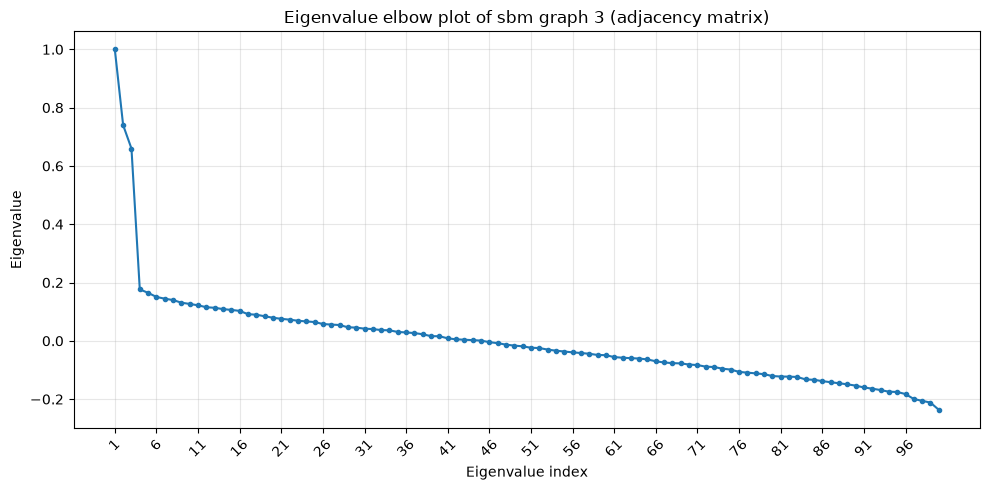

In [21]:
#Spectral gaps
mode = "sbm"
number = 3
matrix = "adjacency"
graph = graph_set[mode][number]
if matrix == "adjacency":
    adj_matrix = stats.adjacency_matrix(graph)
    stats.plot_elbow(adj_matrix, title = f"Eigenvalue elbow plot of {mode} graph {number} ({matrix} matrix)")
elif matrix == "laplacian":
    lap_matrix = stats.laplacian_matrix(graph)
    stats.plot_elbow(lap_matrix, title = f"Eigenvalue elbow plot of {mode} graph {number} ({matrix} matrix)")
elif matrix == "random_walk":
    rw_matrix = stats.random_walk_matrix(graph)
    stats.plot_elbow(rw_matrix, title = f"Eigenvalue elbow plot of {mode} graph {number} ({matrix} matrix)", symmetric = False)

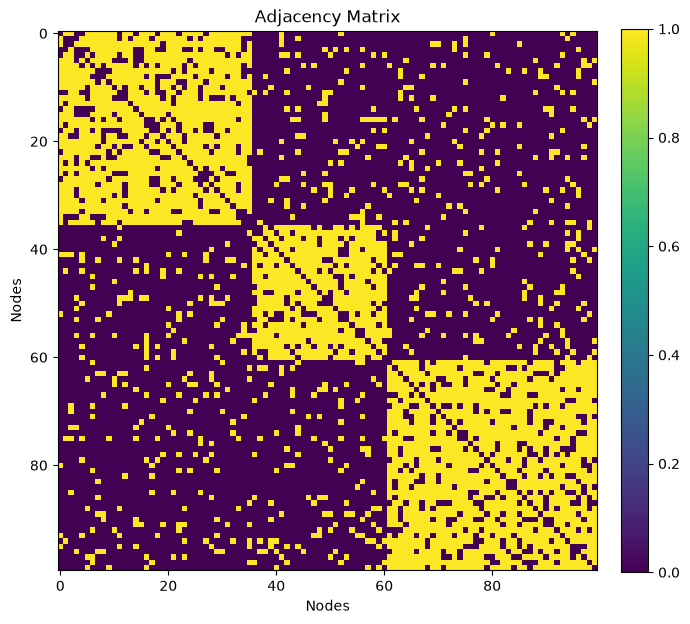

In [22]:
#Plot spectral matrices
mode = "sbm"
number = 3
matrix = "adjacency"
graph = graph_set[mode][number]
if matrix == "adjacency":
    adj_matrix = stats.adjacency_matrix(graph_set[mode][number], normalized = False, sparse = False)
    stats.plot_heatmap(adj_matrix, title = "Adjacency Matrix")
elif matrix == "laplacian":
    lap_matrix = stats.laplacian_matrix(graph_set[mode][number], normalized = True, sparse = False)
    stats.plot_heatmap(lap_matrix, title = "Laplacian Matrix")
elif matrix == "random_walk":
    rw_matrix = stats.random_walk_matrix(graph_set[mode][number], lazy = True, sparse = False)
    stats.plot_heatmap(rw_matrix, title = "Random Walk Matrix")

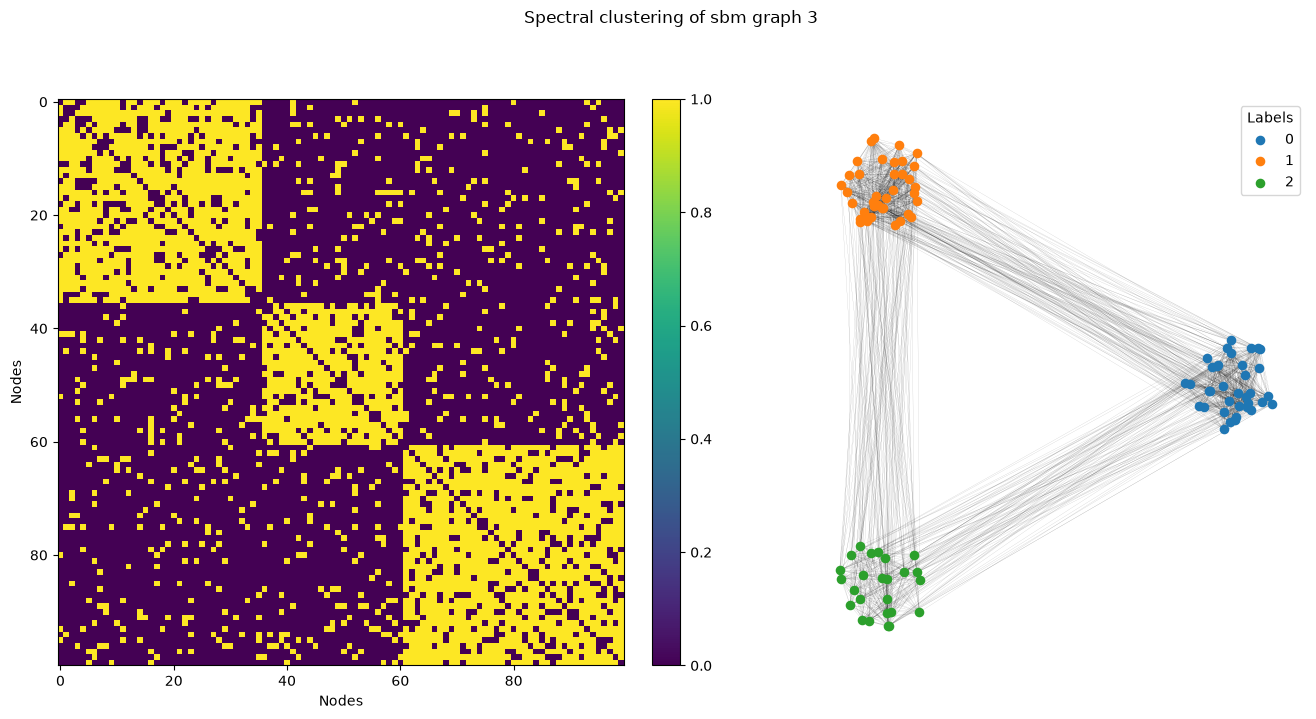

In [23]:
#Spectral clustering
mode = "sbm"
number = 3
graph = graph_set[mode][number]
graph.labels = stats.spectral_clustering(graph)
graphon.plot_graph(graph, title = f"Spectral clustering of {mode} graph {number}")